In [49]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


(41202, 13)
   VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           132           234             1         70.0      0.5   

   tolls_amount  improvement_surcharge  tip_amount  
0          6.94                      1       

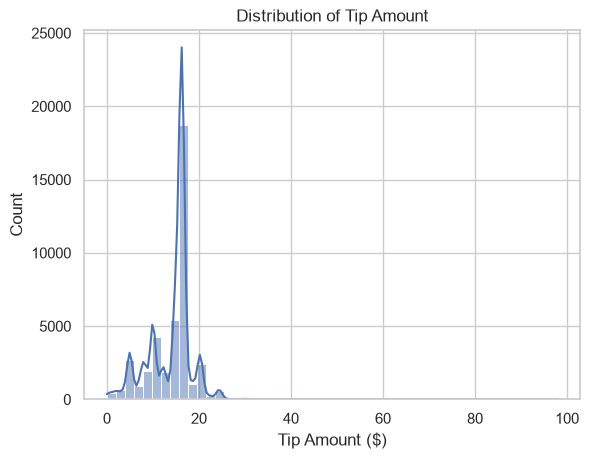

In [50]:

# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)
taxi = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv")

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()
print(taxi.shape)
print(taxi.head())
taxi.info()
taxi.describe()
print(taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.

sns.histplot(taxi['tip_amount'], bins = 50, kde = True)
plt.title('Distribution of Tip Amount')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Count')
plt.show()

The data has a total of 41202 rows and 13 columns. There are no missing or impossible values in the data. The tip_amount distribution is right-skewed, with most of the data being spread across $10 and $20. Since the x axis extends to $100, it means large tips are not many which pulls the tail of the distribution to the right.

This influences my preprocessing because the distribution being right skewed with no outliers means removing large tip values can be removed before training can be considered because the distort the model. Numerical features such as trip_distance and fare_amount are using different scales and would habe to be scaled.

In [51]:
from sklearn.preprocessing import StandardScaler

# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi = taxi[taxi['trip_distance'] > 0]
taxi = taxi[taxi['fare_amount'] > 0]
taxi = taxi[taxi['tip_amount'] >= 0]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']
taxi['additional_charges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge']

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwdå_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
categorical_cols = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']
taxi = pd.get_dummies(taxi, columns = categorical_cols, drop_first = True)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
print(taxi.shape)
print(taxi.head())

(41126, 15)
   passenger_count  trip_distance  PULocationID  DOLocationID  fare_amount  \
0                1          17.63           132           164         70.0   
1                1          19.52           132           236         70.0   
2                1          17.81           132            48         70.0   
3                2          19.30           132           148         70.0   
4                1          18.75           132           234         70.0   

   mta_tax  tolls_amount  improvement_surcharge  tip_amount  fare_per_mile  \
0      0.5          6.94                      1       16.54       3.970505   
1      0.5          6.94                      1       16.19       3.586066   
2      0.5          6.94                      1       12.00       3.930376   
3      0.5          0.00                      1        5.00       3.626943   
4      0.5          6.94                      1       10.00       3.733333   

   additional_charges  RatecodeID_2  RatecodeID_4 

1. There were no missing values to handle. Rows where trip_distance or fare_amount were less than or equal to zero were removed since a trip cannot have zero distance or be free. Rows with negative tip_amount values were also removed since tips cannot be negative.

2. Two new features were engineered: fare_per_mile and additional_charges. fare_per_mile measures how expensive a trip was per mile, which could influence how much a customer would tip. additional_charges combines the mta_tax, tolls_amount, and improvement_surcharge into a single feature to capture the total extra charges associated with a single trip.

3. I chose the StandardScaler. This is because it standardizes numeric features to have a mean of 0 and a standard deviation of 1. This is beneficial because the features use different scales and this method uses the same range for all features, preventing larger-valued features from dominating.

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: Separate features (X) and target (y = tip_amount)
X = taxi.drop(columns = ['tip_amount'])
y = taxi['tip_amount']

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.4, random_state = RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = RANDOM_STATE)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train: (24675, 14), Val: (8225, 14), Test: (8226, 14)


The ratio used was 60/20/20 split, meaning 60% for training, 20% for validation and 20% for testing.

A separate validation set is used to tune and compare the models without using the test set itself. The test set is only used at the end to measure how well the final model performs on data which it has not seen before.

The scaler must be fit on the training data only in order to prevent data leakage. If it is fit on the entire dataset, the information from the validation and test sets which are supposed to be hidden would leak into the model, meaning the evaluation results would be unreliable.

---------- Linear Regression ----------
Train - RMSE: 4.8173, R(^2): 0.0488
Validation - RMSE: 4.7795, R(^2): 0.0689
Test - RMSE: 5.2236, R(^2): 0.0402

---------- Random Forest ----------
Train - RMSE: 2.8251, R(^2): 0.6728
Validation - RMSE: 5.4397, R(^2): -0.2061
Test - RMSE: 5.8156, R(^2): -0.1897


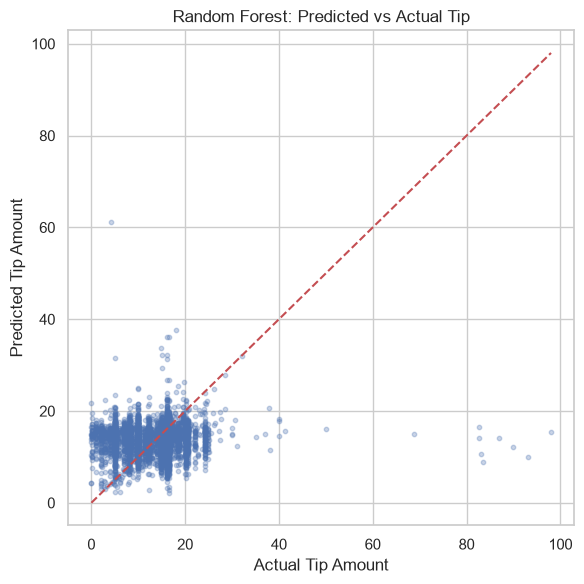

In [53]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

rf = RandomForestRegressor(n_estimators = 100, random_state = RANDOM_STATE)
rf.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test sets.
lr_train_pred = lr.predict(X_train_scaled)
lr_val_pred = lr.predict(X_val_scaled)
lr_test_pred = lr.predict(X_test_scaled)

rf_train_pred = rf.predict(X_train_scaled)
rf_val_pred = rf.predict(X_val_scaled)
rf_test_pred = rf.predict(X_test_scaled)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
print("---------- Linear Regression ----------")
for name, y_true, y_pred in [("Train", y_train, lr_train_pred), ("Validation", y_val, lr_val_pred), ("Test", y_test, lr_test_pred)]:
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{name} - RMSE: {rmse:.4f}, R(^2): {r2:.4f}")
print()

print("---------- Random Forest ----------")
for name, y_true, y_pred in [("Train", y_train, rf_train_pred), ("Validation", y_val, rf_val_pred), ("Test", y_test, rf_test_pred)]:
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{name} - RMSE: {rmse:.4f}, R(^2): {r2:.4f}")

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize = (6,6))
plt.scatter(y_test, rf_test_pred, alpha = 0.3, s = 10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Random Forest: Predicted vs Actual Tip")
plt.tight_layout()
plt.show()

1. Linear Regression performed best on the validation test when compared to Random Forest by producing a lower RMSE of 4.7795 as opposed to 5.4397. For the Random Forest model, I tried 100 values of n_estimators.

2. The Linear Regression model is well-fitting. This is because its RMSE values are similar in the train(4.8173), the validation (4.7795) and the test(5.2236). The Random Foredt model is overfitting because it performs well on the training set (RMSE: 2.8251, R(^2): 0.6728) but much worse on the validation (RMSE: 5.4397, R(^2): -0.2061) and the test (RMSE: 5.8156, R(^2): -0.1897).

3. To reduce the overfitting, I would reduce the complexity of the Random Forest by limiting the tree depth, or tuning other hyperparameters to improve generalisation of the model.

(2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportat

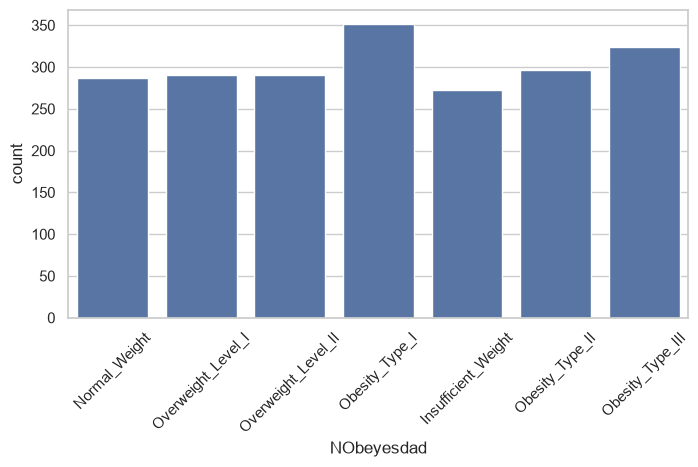

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [54]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv")

# TODO: Inspect shape, head, info, describe, and missing values.
print(obesity.shape)
print(obesity.head())
obesity.info()
obesity.describe()
print(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
print(obesity["NObeyesdad"].value_counts())
plt.figure(figsize = (8, 4))
sns.countplot(x = "NObeyesdad", data = obesity)
plt.xticks(rotation = 45)
plt.show()
print(obesity['NObeyesdad'].value_counts())

There are 2111 rows and 17 columns. The categorical columns are Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS and NObeyesdad. The numeric variables are Age, Height, Weight, FCVC, NPC, CH20, FAF and TUE.

The target is fairly balanced because each class has about 272 to 351 samples. So no class is too large or too small. Class balance is important because the model may become biased towards majority classes and perform well overall but poorly on minority classes.

In [55]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
obesity[binary_cols] = obesity[binary_cols].replace({'yes': 1, 'no': 0})
obesity = pd.get_dummies(obesity, columns = ['Gender', 'MTRANS'], drop_first = True)

freq_order = ['no', 'Sometimes', 'Frequently', 'Always']
ord_encoder = OrdinalEncoder(categories = [freq_order, freq_order])
obesity[['CAEC', 'CALC']] = ord_encoder.fit_transform(obesity[['CAEC', 'CALC']])

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
obesity['NObeyesdad'] = label_encoder.fit_transform(obesity['NObeyesdad'])

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).


1. I encoded the categorical variables (ie. family_history_with_overweight, FAVC, SMOKE, SCC) by using 0,1 mapping because they only had 2 possible values. One hot encoding was used for the nominal variables (Gender, MTRANS) because they do not have a natural order. I used ordinal encoding for the CAEC and CALC because these variables have a clear order which is important to keep.

2. I engineered the BMI feature and this it is fair to include since BMI is directly related to obesity. It may make the prediction easier for the model because of how strongly it correlates to the target but it is still important to include.

3. I used the StandardScaler because it standardises numerical features to have a mean of 0 and a standard deviation of 1. This is important for datasets with different scales because it prevents larger-valued features from dominating.

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: Separate X (features) and y (encoded NObeyesdad).
X = obesity.drop(columns = ['NObeyesdad'])
y = obesity['NObeyesdad']

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, stratify = y_temp, random_state = RANDOM_STATE)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

I used a 70/15/15 split, meaning 70% for training, 15% for validation and 15% for testing. stratify=y is important for the dataset because it endures that the split contains all the obesity classes in similar proportions to the original dataset, keeping the distribution balances for the train, validation and test sets.

If I did not stratify, some of the classes would have been underrepresented or have no split. This would have lead to biased training and an unreliable evaluation since the model might not learn from all the classes properly.

Train - Accuracy: 0.9282, Macro-F1: 0.9258
Val - Accuracy: 0.9085, Macro-F1: 0.9068
Test - Accuracy: 0.8738, Macro-F1: 0.8696

Classification Report (Test):
                     precision    recall  f1-score   support

Insufficient_Weight       0.87      0.98      0.92        41
      Normal_Weight       0.85      0.67      0.75        43
     Obesity_Type_I       0.92      0.89      0.90        53
    Obesity_Type_II       0.94      0.98      0.96        45
   Obesity_Type_III       1.00      0.98      0.99        48
 Overweight_Level_I       0.72      0.79      0.76        43
Overweight_Level_II       0.80      0.82      0.81        44

           accuracy                           0.87       317
          macro avg       0.87      0.87      0.87       317
       weighted avg       0.88      0.87      0.87       317



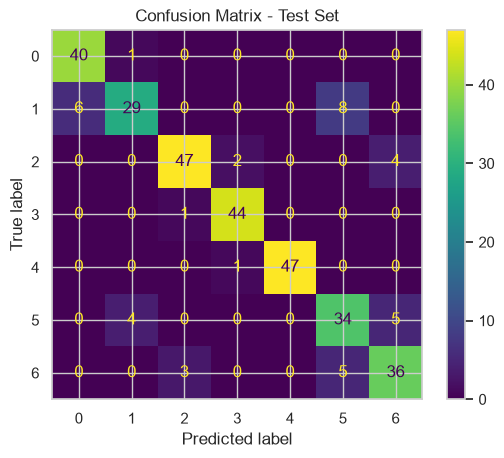

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
clf = LogisticRegression(max_iter = 1000, random_state = RANDOM_STATE)
clf.fit(X_train, y_train)

# TODO: Predict on train, validation, and test.
train_pred = clf.predict(X_train)
val_pred = clf.predict(X_val)
test_pred = clf.predict(X_test)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
for name, y_true, y_pred in [('Train', y_train, train_pred), ('Val', y_val, val_pred), ('Test', y_test, test_pred)]:
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average = 'macro')
    print(f"{name} - Accuracy: {acc:.4f}, Macro-F1: {f1:.4f}")

print()
print("Classification Report (Test):")
print(classification_report(y_test, test_pred, target_names = label_encoder.classes_))

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.title("Confusion Matrix - Test Set")
plt.show()

1. I chose Logistic Regression because it is a simple and fast model used for multi-class problems and works well when the relationships between features and classes are linear.

2. The model shows a drop from training to testing.
Train - Accuracy: 0.9282, Macro-F1: 0.9258
Val - Accuracy: 0.9085, Macro-F1: 0.9068
Test - Accuracy: 0.8738, Macro-F1: 0.8696
Since the training performance is higher than the validation and test, it means that the model shows a bit of overfitting. However, it is still reasonably generalised.

3. From the confusion matrix, the obesity levels which are hardest to tell apart are Normal_Weight and Overweight_Level_I. This is because the classes are close to each other in terms of measurements like the BMI, so their features overlap and make it hard to separate them clearly.

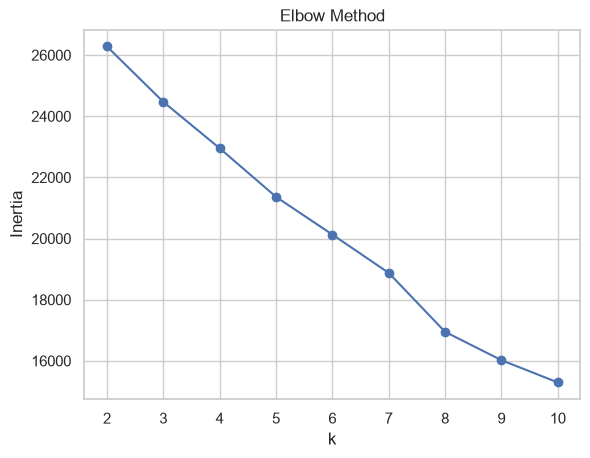

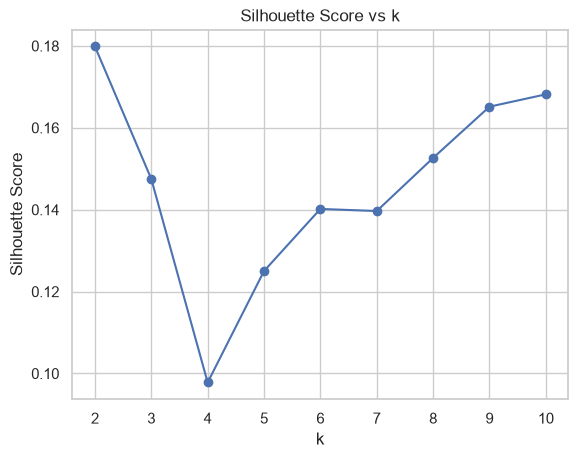

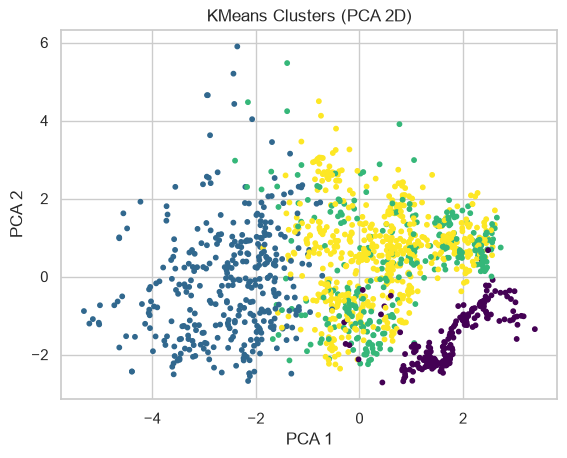

In [58]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_cluster = X_train

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

inertias = []
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = RANDOM_STATE, n_init = 10)
    labels = kmeans.fit_predict(X_cluster)

    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

plt.figure()
plt.plot(range(2, 11), inertias, marker = 'o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show

plt.figure()
plt.plot(range(2, 11), sil_scores, marker = 'o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
k = 4
kmeans = KMeans(n_clusters = k, random_state = RANDOM_STATE, n_init = 10)
cluster_labels = kmeans.fit_predict(X_cluster)

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_2d = pca.fit_transform(X_cluster)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c = cluster_labels, cmap = 'viridis', s = 10)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans Clusters (PCA 2D)")
plt.show()

In [59]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
cluster_vs_true = pd.crosstab(cluster_labels, y_train)
print(cluster_vs_true)

NObeyesdad    0    1    2    3    4    5   6
row_0                                       
0             0    0    4    3  227    1   3
1           139  131    2    1    0   33  40
2             2   25   74   79    0   54  67
3            49   45  165  125    0  115  93


1. The elbow method did not show a clear bend because it kept decreasing, so it was not decisive. The silhouette score peaked at k = 2 (0.18) but k = 4 was chosen. k = 4 was chosen because it gives more useful groups than k =2 without adding too many additional clusters.

2. Cluster 0 maps cleanly to Obesity_Type_III and Cluster 1 captures Insufficient_Weight and Normal_Weight properly. Cluster 2 and 3 break down by mixing a number of the middle obesity classes together since they overlap in feature space.

3. In a real public-health setting where labels are expensive to collect, the clusters can be used to group people in a population by risk level using some basic measurements. This would help direct health resources without needing to formally diagnose every single person.

Section 4 - Reflection

1. Supervised vs Unsupervised
Logistic Regression used labels to learn the direct boundaries of classes and achieved 87% test accuracy. K-Means had no labels so it could only group similar points. It captured the most extreme classes well mixed up the middle obesity classes. Each approach is important and useful meaning Logistic Regression is best for when there are labels and K-Means is best for when there aren't any.

2. Regression vs Classification
Regression measured how far off the predictions were in units (RMSE, R^2). Classification on the other hand measured whether the exact class was correct, so even if it was very close, it still counts as wrong. This made classification easier to evaluate but harsher or stricter when it came to what counts as a correct prediction.

3. Overfitting
The biggest gap was in the Random Forest on the taxi data. This was depicted in the Training and Testing results (ei. Train R^2 = 0.67 and Test R^2 = -0.19). The most effective thing I would do to close it would be limiting the tree depth with max_depth to prevent the model from memorising the training data.